# EDA of the misconception-annotated MathDial dataset

## Purpose

This notebook starts from the final files in `data/misconception`. Part I describes the exact paper-filtered BKT population, including dialogue, turn, KC, correctness, and filtering checks. Part II builds on that foundation with analyses made possible by the P11 misconception annotations.

The annotation analysis keeps two units separate:

- **solution**: the added incorrect-solution unit (turn 0);
- **tagged real turn**: a real student response retained by the paper's BKT preparation.

This distinction prevents the deliberately incorrect solution from being mixed into ordinary turn-level correctness summaries.

## Annotation-state contract

Each unit has one label for each of five misconception families.

| Code | Meaning | Interpretation |
| --- | --- | --- |
| `P` | present | The unit exhibits a misconception in this family. |
| `A` | absent | The construct is engaged and handled without that misconception. |
| `N` | not evidenced | The unit does not provide enough relevant evidence to judge the family. |

`N` is not a synonym for `A`. In particular, a later `N` does not prove that an earlier misconception was resolved. All analyses below preserve this three-state distinction.

In [1]:
import os
import re
import json
from ast import literal_eval
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

for root in [Path.cwd(), *Path.cwd().parents]:
    if (root / 'data' / 'misconception').is_dir():
        os.chdir(root)
        break
else:
    raise FileNotFoundError('Run this notebook from inside the repository.')

from extension.scripts.data_management.load_annotation_data import load_dataset

DATA = Path('data/misconception')
FAMILIES = ['comprehension', 'relevance', 'principles', 'wrong_operation', 'steps']
FAMILY_LABELS = {
    'comprehension': 'Comprehension',
    'relevance': 'Relevance',
    'principles': 'Principles',
    'wrong_operation': 'Wrong operation',
    'steps': 'Steps',
}
LABEL_ORDER = ['P', 'A', 'N']
LABEL_COLORS = {'P': '#C44E52', 'A': '#55A868', 'N': '#B8BDC7'}
SPLIT_COLORS = {'train': '#4C72B0', 'test': '#DD8452'}
plt.style.use('seaborn-v0_8-whitegrid')

raw = {
    split: load_dataset(DATA / f'mathdial_{split}.csv')
    for split in ['train', 'test']
}

raw_summary = pd.DataFrame([
    {
        'split': split,
        'dialogues': frame['dialogue_id'].nunique(),
        'rows': len(frame),
        'solution_rows': frame['turn'].eq('solution').sum(),
        'real_turn_rows': frame['turn'].ne('solution').sum(),
    }
    for split, frame in raw.items()
]).set_index('split')

for split, frame in raw.items():
    assert frame.groupby('dialogue_id')['turn'].apply(lambda x: x.eq('solution').sum()).eq(1).all()
    assert frame[FAMILIES].isin(LABEL_ORDER).all().all()

print('working directory:', Path.cwd())
display(raw_summary)
print('All annotation cells contain P, A, or N.')

working directory: /Users/tandon.utsav2/Desktop/Experiment_1


,dialogues,rows,solution_rows,real_turn_rows
split,,,,
train,2253,15609,2253,13356
test,595,3902,595,3307


All annotation cells contain P, A, or N.


# Part I — Paper-filtered MathDial EDA

## Paper preparation contract

For both splits, the paper keeps typicality scores of at least 1, removes a whole dialogue when its ATC annotation failed, removes turns without both KCs and correctness, applies the human final-turn correctness override, and retains dialogues with at least two tagged real turns. Only after that does it expand each retained turn to one row per KC.

The flattened files contain enough information to apply those operations directly. A failed ATC dialogue is identifiable because every real turn has neither a correctness annotation nor any KCs. The added solution row is excluded throughout Part I so this section describes the paper's original BKT population.

In [2]:
def parse_kcs(value):
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = literal_eval(text)
    except (SyntaxError, ValueError):
        return []
    return parsed if isinstance(parsed, list) else []

def parse_correct(value):
    text = str(value).strip().lower()
    if text == 'true':
        return True
    if text == 'false':
        return False
    return None

def turn_number(value):
    match = re.search(r'\d+', str(value))
    return int(match.group()) if match else None

def paper_prepare(units, split):
    work = units.copy()
    work['kcs_list'] = work['kcs'].map(parse_kcs)
    work['correct_value'] = work['correct'].map(parse_correct)
    work['turn_number'] = work['turn'].map(turn_number)

    typical_mask = (
        pd.to_numeric(work['self-typical-confusion']) >= 1
    ) & (
        pd.to_numeric(work['self-typical-interactions']) >= 1
    )
    typical_ids = set(work.loc[typical_mask, 'dialogue_id'])
    typical = work[work['dialogue_id'].isin(typical_ids)].copy()

    failed = short = eligible_overrides = changed_overrides = 0
    kept_ids, turn_rows, pseudo_rows = [], [], []

    for dialogue_id, group in typical.groupby('dialogue_id', sort=False):
        real = group[group['turn'].ne('solution')].sort_values('turn_number')
        records = []
        for _, row in real.iterrows():
            correct = row['correct_value'] if row['kcs_list'] else None
            records.append({
                'dialogue_id': int(dialogue_id),
                'turn': int(row['turn_number']),
                'correct': correct,
                'kcs': row['kcs_list'],
                'family': row['family'],
                **{family: row[family] for family in FAMILIES},
            })

        if not any(item['correct'] is not None or item['kcs'] for item in records):
            failed += 1
            continue

        if records and records[-1]['kcs'] and records[-1]['correct'] is not None:
            eligible_overrides += 1
            before = records[-1]['correct']
            outcome = str(real.iloc[-1]['self-correctness'])
            records[-1]['correct'] = {
                'Yes': True,
                'No': False,
                'Yes, but I had to reveal the answer': None,
            }.get(outcome, before)
            changed_overrides += records[-1]['correct'] != before

        tagged = [item for item in records if item['correct'] is not None and item['kcs']]
        if len(tagged) < 2:
            short += 1
            continue

        kept_ids.append(int(dialogue_id))
        for real_rank, item in enumerate(tagged, start=1):
            turn_rows.append({
                **item,
                'real_rank': real_rank,
                'n_real_tagged': len(tagged),
                'n_kcs': len(item['kcs']),
            })
            for kc in item['kcs']:
                pseudo_rows.append({
                    'dialogue_id': int(dialogue_id),
                    'turn': item['turn'],
                    'correct': int(item['correct']),
                    'kc': str(kc),
                })

    dialogues = (
        typical[typical['dialogue_id'].isin(kept_ids)]
        .drop_duplicates('dialogue_id')
        .set_index('dialogue_id', drop=False)
    )
    turns = pd.DataFrame(turn_rows)
    long = pd.DataFrame(pseudo_rows)
    audit = {
        'split': split,
        'raw_dialogues': units['dialogue_id'].nunique(),
        'after_typical_cutoff_1': len(typical_ids),
        'failed_dialogues_removed': failed,
        'fewer_than_2_tagged_removed': short,
        'dialogues_kept': len(dialogues),
        'tagged_true_turns': len(turns),
        'kc_pseudo_observations': len(long),
        'distinct_kcs': long['kc'].nunique(),
        'test_style_scored_turns': len(turns) - len(dialogues),
        'eligible_final_overrides': eligible_overrides,
        'changed_or_removed_by_override': changed_overrides,
    }
    return {'dialogues': dialogues, 'turns': turns, 'long': long, 'audit': audit}

paper = {split: paper_prepare(frame, split) for split, frame in raw.items()}
audit = pd.DataFrame([paper[split]['audit'] for split in ['train', 'test']]).set_index('split')
display(audit)

,raw_dialogues,after_typical_cutoff_1,failed_dialogues_removed,fewer_than_2_tagged_removed,dialogues_kept,tagged_true_turns,kc_pseudo_observations,distinct_kcs,test_style_scored_turns,eligible_final_overrides,changed_or_removed_by_override
split,,,,,,,,,,,
train,2253,2253,18,185,2050,10448,23953,138,8398,1887,413
test,595,595,7,73,515,2500,5788,94,1985,501,118


In [3]:
EXPECTED = {
    'train': {
        'raw_dialogues': 2253, 'failed_dialogues_removed': 18,
        'fewer_than_2_tagged_removed': 185, 'dialogues_kept': 2050,
        'tagged_true_turns': 10448, 'kc_pseudo_observations': 23953,
        'distinct_kcs': 138,
    },
    'test': {
        'raw_dialogues': 595, 'failed_dialogues_removed': 7,
        'fewer_than_2_tagged_removed': 73, 'dialogues_kept': 515,
        'tagged_true_turns': 2500, 'kc_pseudo_observations': 5788,
        'distinct_kcs': 94, 'test_style_scored_turns': 1985,
    },
}
for split, fields in EXPECTED.items():
    for field, expected in fields.items():
        observed = int(audit.loc[split, field])
        assert observed == expected, f'{split}.{field}: expected {expected}, observed {observed}'

for split in ['train', 'test']:
    turns, long = paper[split]['turns'], paper[split]['long']
    assert not turns['correct'].isna().any()
    assert turns.groupby('dialogue_id').size().ge(2).all()
    assert long.groupby(['dialogue_id', 'turn'])['correct'].nunique().eq(1).all()

print('Paper-filter replication checks: PASSED')

Paper-filter replication checks: PASSED


## Cluster 1 — Dataset shape and correctness

Correctness is counted once per true turn. The pseudo-observation rate is shown only to expose the small weighting change caused when multi-KC turns are expanded.

,dialogues,true_turns,pseudo_observations,fraction_correct,majority_accuracy,mean_turns_per_dialogue,median_turns_per_dialogue,min_turns,max_turns,mean_kcs_per_turn
split,,,,,,,,,,
train,2050,10448,23953,0.498,0.502,5.097,5.0,2,20,2.293
test,515,2500,5788,0.460,0.540,4.854,4.0,2,13,2.315


Correctness by counting unit:


,correct_per_true_turn,correct_per_pseudo_observation
split,,
train,0.498,0.497
test,0.460,0.460


Paper-scored test turns: 1,985 | correct=0.474 | majority accuracy=0.526


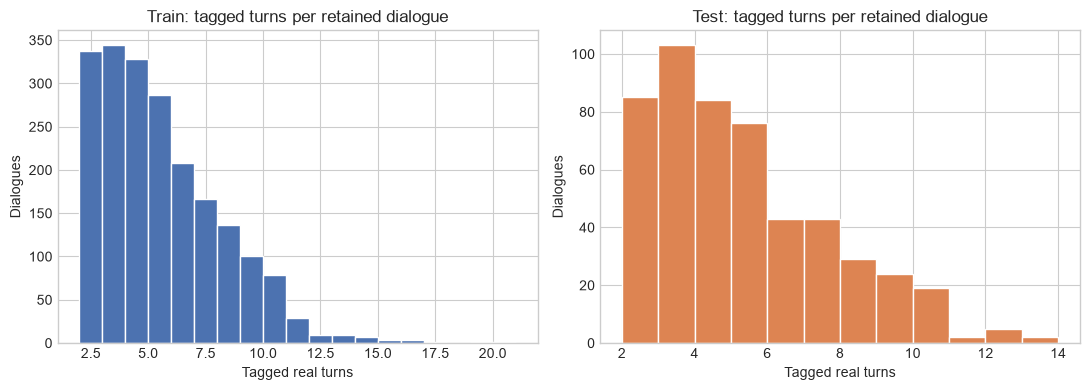

In [4]:
shape_rows, correctness_rows = [], []
for split in ['train', 'test']:
    dialogues = paper[split]['dialogues']
    turns = paper[split]['turns']
    long = paper[split]['long']
    lengths = turns.groupby('dialogue_id').size()
    fraction_correct = turns['correct'].mean()
    shape_rows.append({
        'split': split, 'dialogues': len(dialogues), 'true_turns': len(turns),
        'pseudo_observations': len(long), 'fraction_correct': fraction_correct,
        'majority_accuracy': max(fraction_correct, 1 - fraction_correct),
        'mean_turns_per_dialogue': lengths.mean(),
        'median_turns_per_dialogue': lengths.median(),
        'min_turns': lengths.min(), 'max_turns': lengths.max(),
        'mean_kcs_per_turn': len(long) / len(turns),
    })
    correctness_rows.append({
        'split': split,
        'correct_per_true_turn': turns['correct'].mean(),
        'correct_per_pseudo_observation': long['correct'].mean(),
    })

shape_summary = pd.DataFrame(shape_rows).set_index('split')
correctness_summary = pd.DataFrame(correctness_rows).set_index('split')
display(shape_summary.round(3))
print('Correctness by counting unit:')
display(correctness_summary.round(3))

test_turns = paper['test']['turns']
test_scored = test_turns[test_turns['real_rank'].gt(1)]
print(
    f"Paper-scored test turns: {len(test_scored):,} | "
    f"correct={test_scored['correct'].mean():.3f} | "
    f"majority accuracy={max(test_scored['correct'].mean(), 1-test_scored['correct'].mean()):.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split in zip(axes, ['train', 'test']):
    lengths = paper[split]['turns'].groupby('dialogue_id').size()
    ax.hist(lengths, bins=range(int(lengths.min()), int(lengths.max()) + 2),
            color=SPLIT_COLORS[split], edgecolor='white')
    ax.set(title=f'{split.title()}: tagged turns per retained dialogue',
           xlabel='Tagged real turns', ylabel='Dialogues')
plt.tight_layout()
plt.show()

## Cluster 2 — Knowledge components

These diagnostics cover KC frequency, rare and degenerate KCs, KCs per turn, and train/test coverage. They diagnose estimation uncertainty; they do not introduce an extra filter.

,value
KCs in dictionary,149
observed train KCs,138
observed test KCs,94
train KCs occurring once,12
train KCs occurring at most twice,21
train KCs occurring at most five times,45
degenerate train KCs,20
degenerate pseudo-observations,37
test-only KCs,6
true test turns affected by test-only KCs,11


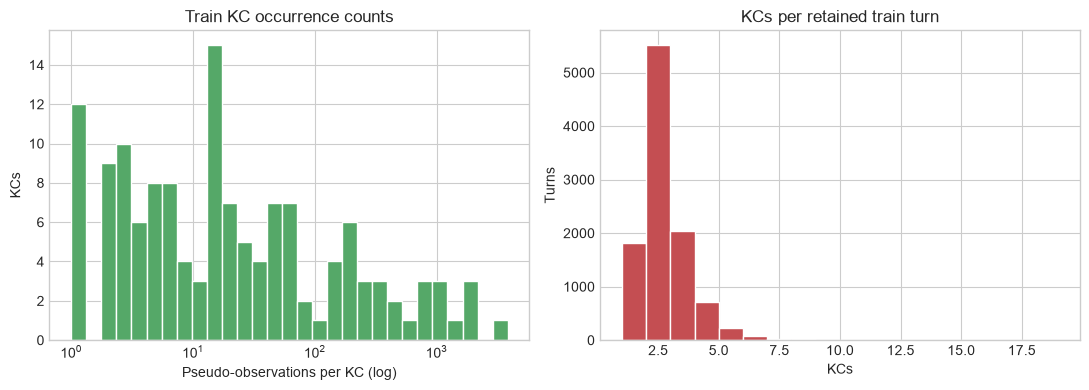

In [5]:
kc_dict = json.loads(Path('data/annotated/kc_dict_mathdial_atc.json').read_text())
train_long, test_long = paper['train']['long'], paper['test']['long']
train_kc_stats = train_long.groupby('kc')['correct'].agg(n='count', n_correct='sum')
test_kc_stats = test_long.groupby('kc')['correct'].agg(n='count', n_correct='sum')
degenerate = train_kc_stats[(train_kc_stats['n_correct'] == 0) | (train_kc_stats['n_correct'] == train_kc_stats['n'])]
train_kcs, test_kcs = set(train_long['kc']), set(test_long['kc'])
test_only = test_kcs - train_kcs
test_only_turns = test_long.loc[test_long['kc'].isin(test_only), ['dialogue_id', 'turn']].drop_duplicates()

kc_summary = pd.Series({
    'KCs in dictionary': len(kc_dict),
    'observed train KCs': len(train_kc_stats),
    'observed test KCs': len(test_kc_stats),
    'train KCs occurring once': int((train_kc_stats['n'] == 1).sum()),
    'train KCs occurring at most twice': int((train_kc_stats['n'] <= 2).sum()),
    'train KCs occurring at most five times': int((train_kc_stats['n'] <= 5).sum()),
    'degenerate train KCs': len(degenerate),
    'degenerate pseudo-observations': int(degenerate['n'].sum()),
    'test-only KCs': len(test_only),
    'true test turns affected by test-only KCs': len(test_only_turns),
}, name='value')
display(kc_summary.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_kc_stats['n'], bins=np.logspace(0, np.log10(train_kc_stats['n'].max()), 30),
             color='#55A868', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set(title='Train KC occurrence counts', xlabel='Pseudo-observations per KC (log)', ylabel='KCs')
axes[1].hist(paper['train']['turns']['n_kcs'],
             bins=range(1, int(paper['train']['turns']['n_kcs'].max()) + 2),
             color='#C44E52', edgecolor='white')
axes[1].set(title='KCs per retained train turn', xlabel='KCs', ylabel='Turns')
plt.tight_layout()
plt.show()

## Cluster 3 — Native MathDial misconception structure

MathDial supplies a broad `student_profile` family and a nearly unique free-text teacher description. These are descriptive context rather than additional BKT filters.

Retained dialogues by native profile family:


,train,test
family,,
comprehension,382,89
principles,352,97
relevance,293,86
wrong-operation,352,93
steps,333,72
problem-type,338,78


Mean true-turn correctness by native profile family:


,train,test
family,,
comprehension,0.502,0.474
principles,0.517,0.440
relevance,0.486,0.469
wrong-operation,0.479,0.496
steps,0.507,0.479
problem-type,0.500,0.402


Teacher-described-confusion uniqueness:


,dialogues,distinct_described_confusions,fraction_unique
split,,,
train,2050,2040,0.995
test,515,513,0.996


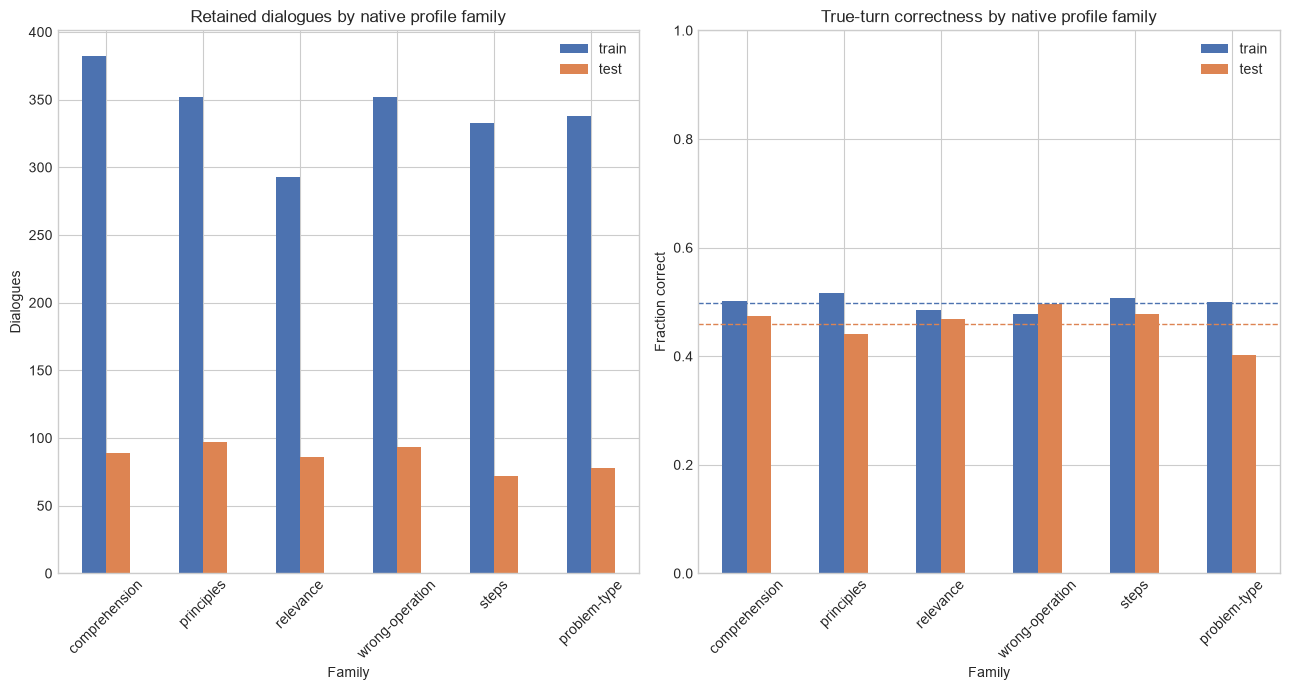

In [6]:
native_order = ['comprehension', 'principles', 'relevance', 'wrong-operation', 'steps', 'problem-type']
family_counts = pd.concat({
    split: paper[split]['dialogues']['family'].value_counts().reindex(native_order)
    for split in ['train', 'test']
}, axis=1).fillna(0).astype(int)
family_correctness = pd.concat({
    split: paper[split]['turns'].groupby('family')['correct'].mean().reindex(native_order)
    for split in ['train', 'test']
}, axis=1)
confusion_uniqueness = pd.DataFrame([
    {
        'split': split, 'dialogues': len(paper[split]['dialogues']),
        'distinct_described_confusions': paper[split]['dialogues']['teacher_described_confusion'].nunique(),
    }
    for split in ['train', 'test']
]).set_index('split')
confusion_uniqueness['fraction_unique'] = (
    confusion_uniqueness['distinct_described_confusions'] / confusion_uniqueness['dialogues']
)

print('Retained dialogues by native profile family:')
display(family_counts)
print('Mean true-turn correctness by native profile family:')
display(family_correctness.round(3))
print('Teacher-described-confusion uniqueness:')
display(confusion_uniqueness.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
family_counts.plot.bar(ax=axes[0], color=[SPLIT_COLORS['train'], SPLIT_COLORS['test']])
axes[0].set(title='Retained dialogues by native profile family', xlabel='Family', ylabel='Dialogues')
family_correctness.plot.bar(ax=axes[1], color=[SPLIT_COLORS['train'], SPLIT_COLORS['test']])
axes[1].axhline(paper['train']['turns']['correct'].mean(), color=SPLIT_COLORS['train'], ls='--', lw=1)
axes[1].axhline(paper['test']['turns']['correct'].mean(), color=SPLIT_COLORS['test'], ls='--', lw=1)
axes[1].set(title='True-turn correctness by native profile family', xlabel='Family',
            ylabel='Fraction correct', ylim=(0, 1))
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Filtering sensitivity

The table below audits the filtering decisions. Cutoff 1 is inert in this release. Raising the dialogue-length threshold would rapidly shrink the benchmark population, while rare or degenerate KCs are an estimation problem better handled by a declared fallback than by deleting observations.

In [7]:
typicality_rows, length_rows = [], []
for split, frame in raw.items():
    dialogues = frame.drop_duplicates('dialogue_id')
    typicality_rows.append({
        'split': split,
        'cutoff_1': ((pd.to_numeric(dialogues['self-typical-confusion']) >= 1) &
                     (pd.to_numeric(dialogues['self-typical-interactions']) >= 1)).sum(),
        'cutoff_2': ((pd.to_numeric(dialogues['self-typical-confusion']) >= 2) &
                     (pd.to_numeric(dialogues['self-typical-interactions']) >= 2)).sum(),
    })
    lengths = paper[split]['turns'].groupby('dialogue_id').size()
    for minimum in [2, 3, 4, 5, 6]:
        length_rows.append({
            'split': split, 'minimum_tagged_turns': minimum,
            'dialogues_kept': int(lengths.ge(minimum).sum()),
            'fraction_of_paper_population': lengths.ge(minimum).mean(),
        })

typicality = pd.DataFrame(typicality_rows).set_index('split')
length_sensitivity = pd.DataFrame(length_rows)
override_summary = audit[['eligible_final_overrides', 'changed_or_removed_by_override']].copy()
override_summary['fraction_changed_or_removed'] = (
    override_summary['changed_or_removed_by_override'] / override_summary['eligible_final_overrides']
)
print('Final-turn override impact:')
display(override_summary.round(3))
print('Typicality retention before other filters:')
display(typicality)
print('Additional minimum-length sensitivity:')
display(length_sensitivity.pivot(index='minimum_tagged_turns', columns='split',
                                 values=['dialogues_kept', 'fraction_of_paper_population']).round(3))

Final-turn override impact:


,eligible_final_overrides,changed_or_removed_by_override,fraction_changed_or_removed
split,,,
train,1887,413,0.219
test,501,118,0.236


Typicality retention before other filters:


,cutoff_1,cutoff_2
split,,
train,2253,2021
test,595,541


Additional minimum-length sensitivity:


dialogues_kept         fraction_of_paper_population  \
split                          test   train                         test   
minimum_tagged_turns                                                       
2                             515.0  2050.0                        1.000   
3                             430.0  1713.0                        0.835   
4                             327.0  1369.0                        0.635   
5                             243.0  1041.0                        0.472   
6                             167.0   754.0                        0.324   

                             
split                 train  
minimum_tagged_turns         
2                     1.000  
3                     0.836  
4                     0.668  
5                     0.508  
6                     0.368

# Part II — EDA of the P11 annotations

## Construct the model-aligned annotation population

For comparability, the annotation plots use the dialogues retained in Part I. Each retained dialogue contributes its solution row and its paper-usable tagged real turns. Untagged real turns remain in the stored dataset but are not mixed into these model-facing summaries.

The integrity audit covers every saved row before this restriction. It checks label completeness, source coverage for every `P`, and the expected one dialogue-thread record per dialogue. The thread JSON is preserved but is not analysed here because this project does not use thread-level scoring.

In [8]:
model_parts, integrity_rows = [], []
for split, frame in raw.items():
    kept_ids = set(paper[split]['dialogues']['dialogue_id'])
    solutions = frame[frame['dialogue_id'].isin(kept_ids) & frame['turn'].eq('solution')].copy()
    solutions['split'] = split
    solutions['role'] = 'solution'
    solutions['turn_number'] = 0
    solutions['real_rank'] = 0
    solutions['correct_value'] = False

    real = paper[split]['turns'].copy()
    real['split'] = split
    real['role'] = 'tagged real turn'
    real['turn_number'] = real['turn']
    real['correct_value'] = real['correct'].astype(bool)

    shared = ['split', 'dialogue_id', 'role', 'turn_number', 'real_rank',
              'correct_value', 'family', *FAMILIES]
    model_parts.extend([solutions[shared], real[shared]])

    p_cells = sum(frame[family].eq('P').sum() for family in FAMILIES)
    p_with_source = sum(
        (frame[family].eq('P') & frame[f'{family}_src'].astype(str).str.strip().ne('')).sum()
        for family in FAMILIES
    )
    integrity_rows.append({
        'split': split, 'rows': len(frame), 'dialogues': frame['dialogue_id'].nunique(),
        'annotation_cells': len(frame) * len(FAMILIES),
        'valid_P_A_N_cells': int(frame[FAMILIES].isin(LABEL_ORDER).sum().sum()),
        'P_cells': int(p_cells), 'P_cells_with_source': int(p_with_source),
        'solution_rows_with_dialogue_threads': int(
            frame.loc[frame['turn'].eq('solution'), 'dialogue_threads'].astype(str).str.strip().ne('').sum()
        ),
    })

model_units = pd.concat(model_parts, ignore_index=True)
integrity = pd.DataFrame(integrity_rows).set_index('split')
assert integrity['annotation_cells'].eq(integrity['valid_P_A_N_cells']).all()
assert integrity['P_cells'].eq(integrity['P_cells_with_source']).all()
assert integrity['solution_rows_with_dialogue_threads'].eq(integrity['dialogues']).all()

model_scope = model_units.groupby(['split', 'role']).size().unstack(fill_value=0)
display(integrity)
print('Model-aligned annotation units:')
display(model_scope)

,rows,dialogues,annotation_cells,valid_P_A_N_cells,P_cells,P_cells_with_source,solution_rows_with_dialogue_threads
split,,,,,,,
train,15609,2253,78045,78045,9399,9399,2253
test,3902,595,19510,19510,2483,2483,595


Model-aligned annotation units:


role,solution,tagged real turn
split,,
test,515,2500
train,2050,10448


## Annotation cluster 1 — State composition

The four panels compare the three-state composition by split and unit role. A high `N` rate means the construct is often not engaged; it should not be interpreted as evidence that students lack that misconception.

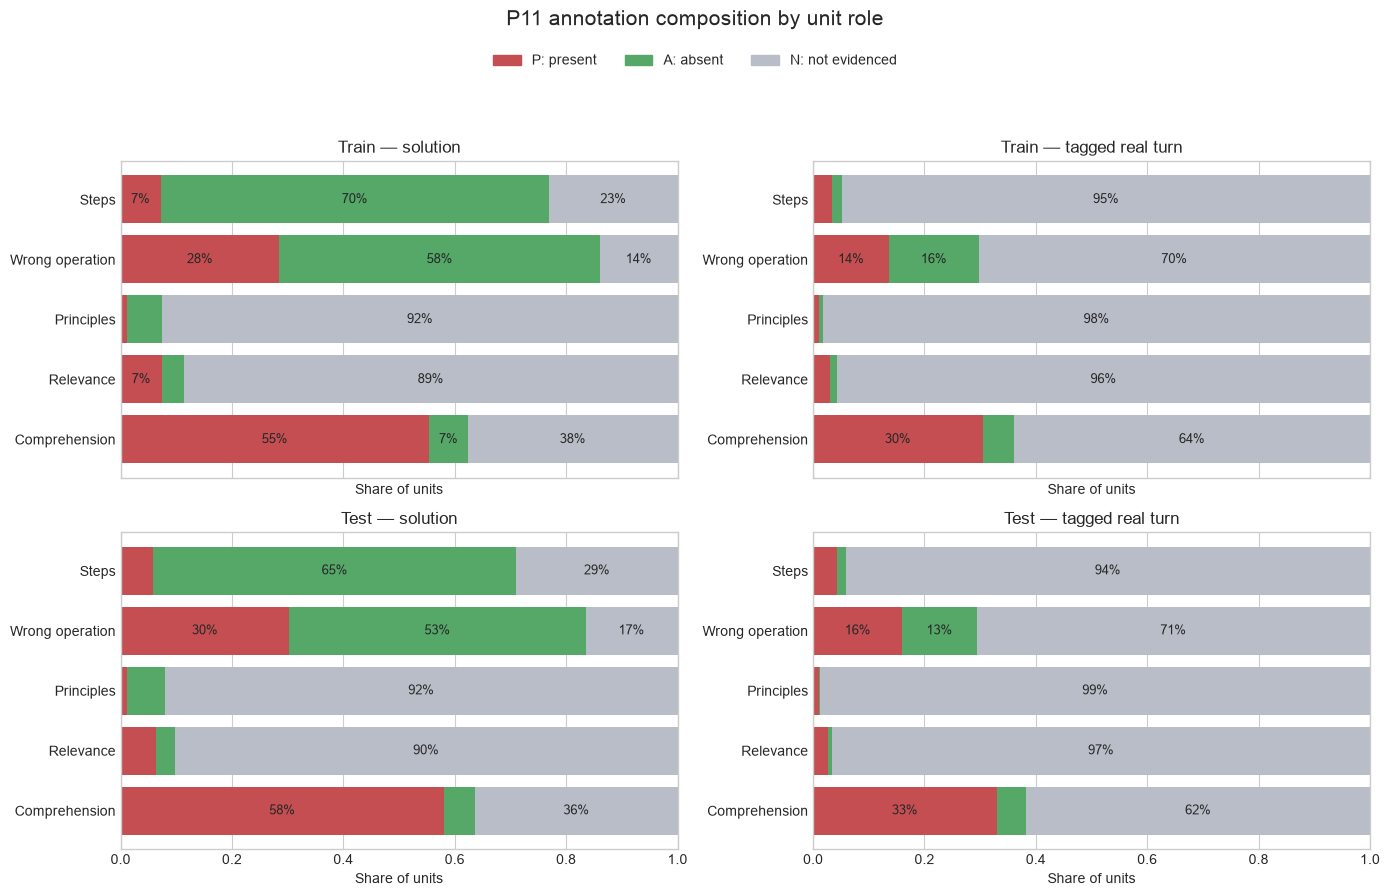

Combined train/test shares:


solution               tagged real turn              
                       P      A      N                P      A      N
comprehension      0.559  0.067  0.373            0.309  0.055  0.635
relevance          0.072  0.038  0.890            0.029  0.012  0.959
principles         0.011  0.065  0.924            0.010  0.007  0.983
wrong_operation    0.288  0.567  0.144            0.141  0.155  0.703
steps              0.069  0.688  0.242            0.036  0.017  0.947

In [9]:
def label_shares(frame):
    return pd.DataFrame({
        family: frame[family].value_counts(normalize=True).reindex(LABEL_ORDER, fill_value=0)
        for family in FAMILIES
    }).T

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
composition_rows = []
for row, split in enumerate(['train', 'test']):
    for col, role in enumerate(['solution', 'tagged real turn']):
        ax = axes[row, col]
        subset = model_units[(model_units['split'] == split) & (model_units['role'] == role)]
        shares = label_shares(subset)
        left = np.zeros(len(FAMILIES))
        y = np.arange(len(FAMILIES))
        for label in LABEL_ORDER:
            values = shares[label].to_numpy()
            ax.barh(y, values, left=left, color=LABEL_COLORS[label], label=label)
            for index, (start, value) in enumerate(zip(left, values)):
                if value >= 0.07:
                    ax.text(start + value / 2, index, f'{value:.0%}', ha='center', va='center', fontsize=9)
            left += values
        ax.set_yticks(y, [FAMILY_LABELS[f] for f in FAMILIES])
        ax.set_xlim(0, 1)
        ax.set_title(f'{split.title()} — {role}')
        ax.set_xlabel('Share of units')
        for family in FAMILIES:
            composition_rows.append({'split': split, 'role': role, 'family': family, **shares.loc[family].to_dict()})

handles = [plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS[label]) for label in LABEL_ORDER]
fig.suptitle('P11 annotation composition by unit role', y=0.99, fontsize=15)
fig.legend(handles, ['P: present', 'A: absent', 'N: not evidenced'],
           loc='upper center', bbox_to_anchor=(0.5, 0.955), ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

composition = pd.DataFrame(composition_rows)
print('Combined train/test shares:')
combined_composition = pd.concat({
    role: label_shares(model_units[model_units['role'].eq(role)])
    for role in ['solution', 'tagged real turn']
}, axis=1)
display(combined_composition.round(3))

## Annotation cluster 2 — Initial misconception burden

This plot counts how many misconception families are simultaneously `P` in each solution. It shows whether the initial evidence is usually concentrated in one family or distributed across multiple independent misconceptions.

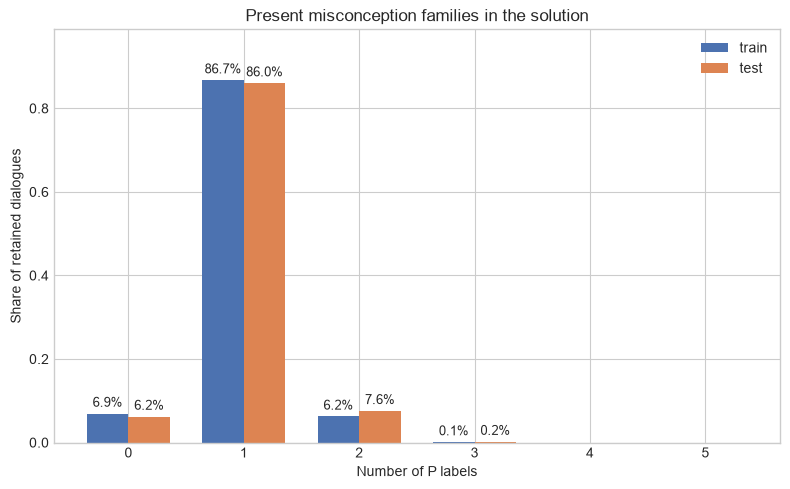

Combined solution misconception-count distribution:


,fraction
n_present,
0,0.068
1,0.866
2,0.065
3,0.001


In [10]:
solutions = model_units[model_units['role'].eq('solution')].copy()
solutions['n_present'] = solutions[FAMILIES].eq('P').sum(axis=1)
burden = pd.crosstab(solutions['n_present'], solutions['split'], normalize='columns').reindex(range(6), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(6)
width = 0.36
for offset, split in zip([-width/2, width/2], ['train', 'test']):
    bars = ax.bar(x + offset, burden[split], width=width,
                  color=SPLIT_COLORS[split], label=split)
    ax.bar_label(bars, labels=[f'{value:.1%}' if value > 0 else '' for value in burden[split]],
                 padding=3, fontsize=9)
ax.set(title='Present misconception families in the solution',
       xlabel='Number of P labels', ylabel='Share of retained dialogues', xticks=x)
ax.set_ylim(0, max(burden.max()) * 1.14)
ax.legend()
plt.tight_layout()
plt.show()

print('Combined solution misconception-count distribution:')
display(solutions['n_present'].value_counts(normalize=True).sort_index().rename('fraction').to_frame().round(3))

## Annotation cluster 3 — Dialogue-level `P → A` transitions

For each dialogue and family, scan the solution and tagged real turns in order. A dialogue counts as an observed `P → A` transition when an `A` occurs after an earlier `P`. Intervening `N` states are retained but do not settle the transition because they provide no evidence about the family.

The analysis also distinguishes a `P → A` transition followed by a later `P`. This prevents a temporary absence from being presented as durable resolution. Percentages use dialogues containing at least one `P` for that family as their denominator.

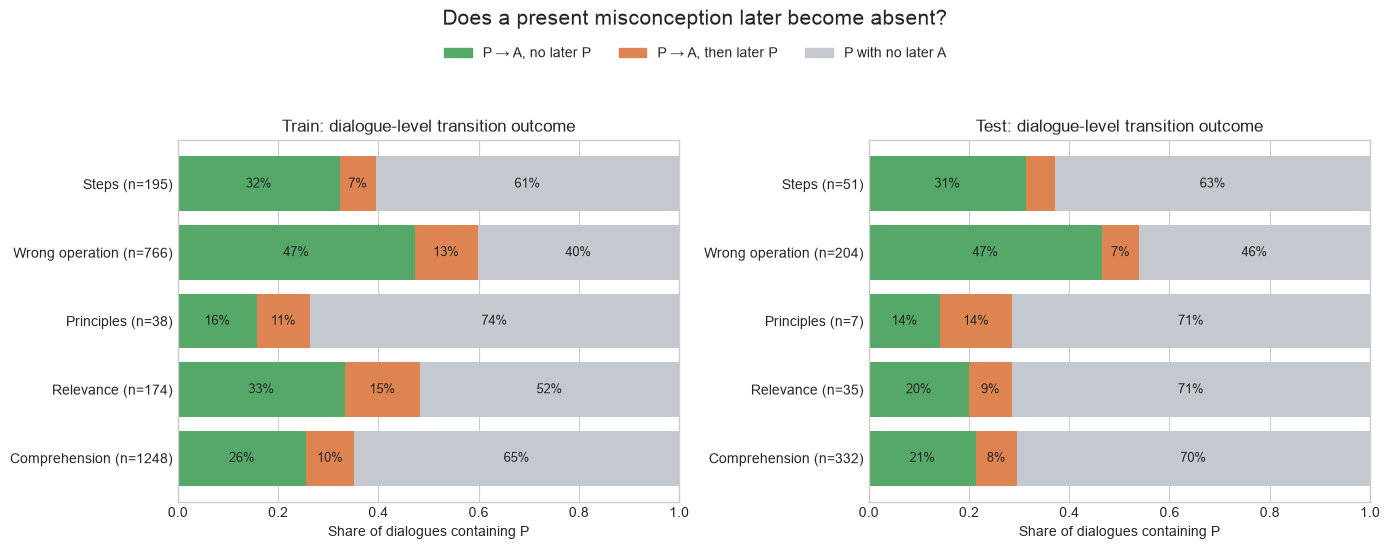

dialogues_with_P  ever_P_to_A  ever_P_to_A_rate  \
split family                                                             
train comprehension                1248          439             0.352   
      relevance                     174           84             0.483   
      principles                     38           10             0.263   
      wrong_operation               766          458             0.598   
      steps                         195           77             0.395   
test  comprehension                 332           98             0.295   
      relevance                      35           10             0.286   
      principles                      7            2             0.286   
      wrong_operation               204          110             0.539   
      steps                          51           19             0.373   

                       P_to_A_then_later_P  last_informative_A_rate  
split family                                                         
train comprehension                    120                    0.275  
      relevance                         26                    0.362  
      principles                         4                    0.211  
      wrong_operation                   96                    0.508  
      steps                             14                    0.333  
test  comprehension                     27                    0.226  
      relevance                          3                    0.200  
      principles                         1                    0.143  
      wrong_operation                   15                    0.475  
      steps                              3                    0.314

In [11]:
real_units = model_units[model_units['role'].eq('tagged real turn')].copy()
ordered_units = model_units.sort_values(['split', 'dialogue_id', 'real_rank'])
transition_rows = []

for (split, dialogue_id), dialogue in ordered_units.groupby(['split', 'dialogue_id'], sort=False):
    for family in FAMILIES:
        states = dialogue[family].tolist()
        if 'P' not in states:
            continue

        seen_p = False
        first_a_after_p = None
        for position, state in enumerate(states):
            if state == 'P':
                seen_p = True
            elif state == 'A' and seen_p:
                first_a_after_p = position
                break

        if first_a_after_p is None:
            outcome = 'P with no later A'
        elif 'P' in states[first_a_after_p + 1:]:
            outcome = 'P → A, then later P'
        else:
            outcome = 'P → A, no later P'

        informative = [state for state in states if state != 'N']
        transition_rows.append({
            'split': split, 'dialogue_id': dialogue_id, 'family': family,
            'outcome': outcome,
            'ever_P_to_A': first_a_after_p is not None,
            'later_P_after_first_A': (
                first_a_after_p is not None and 'P' in states[first_a_after_p + 1:]
            ),
            'last_informative_state': informative[-1],
        })

dialogue_transitions = pd.DataFrame(transition_rows)
outcome_order = ['P → A, no later P', 'P → A, then later P', 'P with no later A']
outcome_colors = {
    'P → A, no later P': '#55A868',
    'P → A, then later P': '#DD8452',
    'P with no later A': '#C4C8CF',
}

summary_rows = []
for split in ['train', 'test']:
    for family in FAMILIES:
        subset = dialogue_transitions[
            dialogue_transitions['split'].eq(split) & dialogue_transitions['family'].eq(family)
        ]
        counts = subset['outcome'].value_counts().reindex(outcome_order, fill_value=0)
        summary_rows.append({
            'split': split, 'family': family, 'dialogues_with_P': len(subset),
            'ever_P_to_A': int(subset['ever_P_to_A'].sum()),
            'ever_P_to_A_rate': subset['ever_P_to_A'].mean(),
            'P_to_A_then_later_P': int(subset['later_P_after_first_A'].sum()),
            'last_informative_A_rate': subset['last_informative_state'].eq('A').mean(),
            **{outcome: int(counts[outcome]) for outcome in outcome_order},
        })
transition_summary = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, split in zip(axes, ['train', 'test']):
    table = transition_summary[transition_summary['split'].eq(split)].set_index('family').reindex(FAMILIES)
    y = np.arange(len(FAMILIES))
    left = np.zeros(len(FAMILIES))
    for outcome in outcome_order:
        values = table[outcome].to_numpy() / table['dialogues_with_P'].to_numpy()
        ax.barh(y, values, left=left, color=outcome_colors[outcome], label=outcome)
        for index, (start, value) in enumerate(zip(left, values)):
            if value >= 0.07:
                ax.text(start + value / 2, index, f'{value:.0%}', ha='center', va='center', fontsize=9)
        left += values
    ax.set_yticks(y, [
        f"{FAMILY_LABELS[f]} (n={int(table.loc[f, 'dialogues_with_P'])})" for f in FAMILIES
    ])
    ax.set(title=f'{split.title()}: dialogue-level transition outcome',
           xlabel='Share of dialogues containing P', xlim=(0, 1))

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=outcome_colors[x]) for x in outcome_order]
fig.suptitle('Does a present misconception later become absent?', y=0.99, fontsize=15)
fig.legend(legend_handles, outcome_order, loc='upper center',
           bbox_to_anchor=(0.5, 0.945), ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

display(transition_summary.set_index(['split', 'family'])[
    ['dialogues_with_P', 'ever_P_to_A', 'ever_P_to_A_rate',
     'P_to_A_then_later_P', 'last_informative_A_rate']
].round(3))

## Annotation cluster 4 — Relationship with current-turn correctness

This is a descriptive validity check, not a causal model result. The annotation was produced after seeing the current student response, so using the current turn's label to predict that same turn's correctness would leak target information. A forecasting model may use the solution annotation initially and lagged annotations from earlier turns, or treat the current annotation as post-response evidence for the next state update.

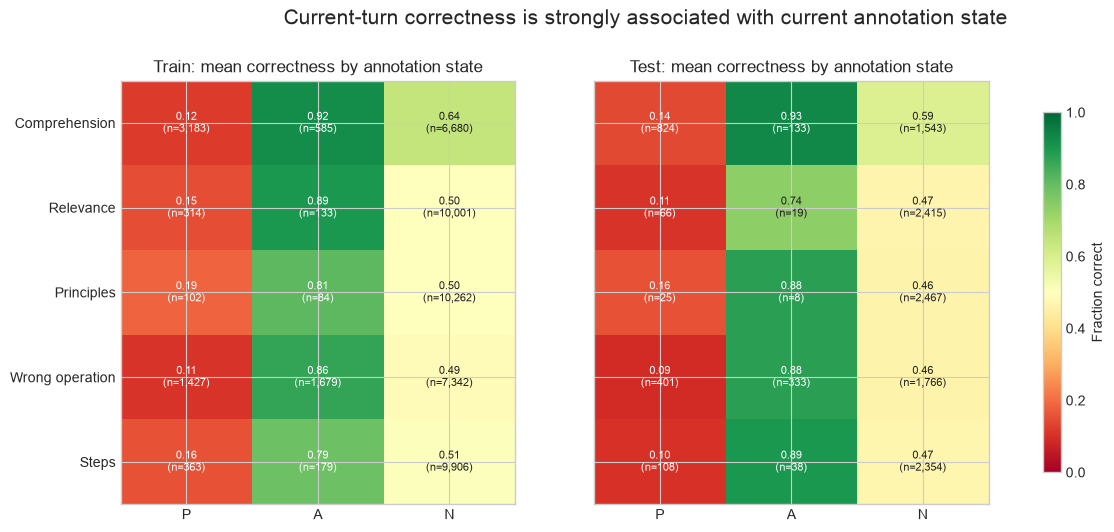

train                 test              
                     P      A      N      P      A      N
comprehension    0.118  0.921  0.642  0.144  0.932  0.587
relevance        0.150  0.895  0.504  0.106  0.737  0.467
principles       0.186  0.810  0.499  0.160  0.875  0.461
wrong_operation  0.106  0.865  0.491  0.092  0.877  0.464
steps            0.157  0.788  0.505  0.102  0.895  0.469

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
correctness_tables = {}
for ax, split in zip(axes, ['train', 'test']):
    subset = real_units[real_units['split'].eq(split)]
    means = pd.DataFrame({
        family: subset.groupby(family)['correct_value'].mean().reindex(LABEL_ORDER)
        for family in FAMILIES
    }).T
    counts = pd.DataFrame({
        family: subset[family].value_counts().reindex(LABEL_ORDER, fill_value=0)
        for family in FAMILIES
    }).T
    correctness_tables[split] = means
    image = ax.imshow(means.to_numpy(dtype=float), aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(3), ['P', 'A', 'N'])
    ax.set_yticks(range(len(FAMILIES)), [FAMILY_LABELS[f] for f in FAMILIES])
    ax.set_title(f'{split.title()}: mean correctness by annotation state')
    for i in range(means.shape[0]):
        for j in range(means.shape[1]):
            value = means.iat[i, j]
            count = int(counts.iat[i, j])
            ax.text(j, i, f'{value:.2f}\n(n={count:,})', ha='center', va='center', fontsize=8,
                    color='white' if value < 0.22 or value > 0.78 else '#222222')
fig.colorbar(image, ax=axes, label='Fraction correct', shrink=0.85)
fig.suptitle('Current-turn correctness is strongly associated with current annotation state', y=1.01, fontsize=15)
plt.show()

correctness_by_state = pd.concat(correctness_tables, axis=1)
display(correctness_by_state.round(3))

# Conclusions and modelling implications

1. **The flattened misconception files recover the paper-filtered BKT population exactly.** The population contains 2,050 train dialogues / 10,448 tagged turns and 515 test dialogues / 2,500 tagged turns. The added solution row does not alter Part I.
2. **Annotation coverage is complete.** Every saved family cell is one of `P`, `A`, or `N`; every `P` cites at least one source; and each dialogue carries its stored thread object on the solution row. No annotation-derived row filter is needed.
3. **The incorrect solution is the richest initial evidence.** Across retained dialogues, most solutions contain exactly one `P`; multiple independent present families occur, but are uncommon. This supports representing misconception evidence as a five-dimensional state rather than forcing one class per dialogue.
4. **Comprehension and wrong operation dominate initial evidence.** This is an empirical property of the P11 annotations, not a reason to discard the rarer relevance, principles, or steps evidence. Rarity should be handled through regularisation or pooling.
5. **Dialogue-level transitions must distinguish observed absence from durable resolution.** A later `A` supplies positive evidence after a `P`, while intervening `N` states say nothing. Cases where `P` reappears after `A` are reported separately rather than being counted as unqualified resolution.
6. **Current annotations are contemporaneous evidence.** Their strong relationship with current correctness is expected, but it also exposes a leakage boundary. For next-turn prediction, use solution evidence at initialisation and only annotations from earlier observed turns.
7. **Do not add annotation-based filtering to the primary population.** Preserve the paper filters for comparability, retain all five family states, and treat sparsity and uncertainty as model-design issues rather than deleting dialogues or families.